In [1]:
import numpy as np
from scipy.stats import qmc   # qmc = quasi-Monte Carlo, has Latin Hypercube

# our 3 parameters and their physical ranges
param_names = ["d", "n1", "n2"]
lower = np.array([20.0, 1.0, 1.4])   # mins
upper = np.array([450.0, 2.5, 1.6])  # maxs

print("parameters:", param_names)
print("lower bounds:", lower)
print("upper bounds:", upper)

parameters: ['d', 'n1', 'n2']
lower bounds: [20.   1.   1.4]
upper bounds: [450.    2.5   1.6]


In [2]:
n_samples = 300   # how many points to scatter in the box

# Latin Hypercube: spread points evenly across the 3D space
sampler = qmc.LatinHypercube(d=3, seed=0)   # d=3 means 3 dimensions (our 3 params)
unit_samples = sampler.random(n=n_samples)   # points in a plain 0-to-1 cube

# stretch the 0-1 cube to our real ranges
samples = qmc.scale(unit_samples, lower, upper)

print("samples shape:", samples.shape)
print("first 3 samples:\n", samples[:3])

samples shape: (300, 3)
first 3 samples:
 [[143.78702158   1.73365107   1.52397268]
 [150.40964372   2.20593365   1.42205816]
 [403.26382205   2.41635252   1.55830425]]


In [3]:
import jax.numpy as jnp

def tmm_single_layer(n0, n1, n2, d, lam):
    # phase thickness of the layer
    delta = 2 * jnp.pi * n1 * d / lam
    # Fresnel coefficients at each interface
    r01 = (n0 - n1) / (n0 + n1)   # air -> layer
    r12 = (n1 - n2) / (n1 + n2)   # layer -> glass
    # Fabry-Perot total reflection coefficient
    r = (r01 + r12 * jnp.exp(2j * delta)) / (1 + r01 * r12 * jnp.exp(2j * delta))
    R = jnp.abs(r)**2
    return R

# quick check: bare glass (d=0) should give R ≈ 0.04
print("d=0 check:", float(tmm_single_layer(1.0, 1.5, 1.5, 0.0, 500.0)))

d=0 check: 0.04000000283122063


In [4]:
# wavelength grid for every spectrum (same 300 points as before)
wavelengths = jnp.linspace(400, 700, 300)

# for one parameter set, compute the full spectrum across wavelengths
def spectrum_for_params(d, n1, n2):
    R_at = lambda lam: tmm_single_layer(1.0, n1, n2, d, lam)  # n0=air=1.0 fixed
    return jnp.vectorize(R_at)(wavelengths)

# run TMM on all 300 sampled recipes
Y = np.array([spectrum_for_params(d, n1, n2) for d, n1, n2 in samples])

print("Y shape:", Y.shape)
print("one spectrum, first 5 wavelengths:", Y[0][:5])

Y shape: (300, 300)
one spectrum, first 5 wavelengths: [0.07542104 0.07479478 0.07417125 0.07355081 0.07293355]


In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler

# X = samples (300,3), Y = spectra (300,300). Convert to plain numpy.
X = np.array(samples)
Y = np.array(Y)

# standardize inputs (d, n1, n2 live on very different scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled mean (should be ~0):", X_scaled.mean(axis=0).round(3))
print("X_scaled std (should be ~1):", X_scaled.std(axis=0).round(3))

X_scaled mean (should be ~0): [-0.  0. -0.]
X_scaled std (should be ~1): [1. 1. 1.]


In [6]:
# build the Gaussian Process: a kernel describes how smooth we expect the mapping to be
kernel = ConstantKernel(1.0) * RBF(length_scale=[1.0, 1.0, 1.0]) + WhiteKernel(noise_level=1e-4)

gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2)

# train on the standardized inputs -> spectra
gp.fit(X_scaled, Y)

print("training done")
print("learned kernel:", gp.kernel_)

training done
learned kernel: 1.05**2 * RBF(length_scale=[3.83e+03, 1.77, 17.3]) + WhiteKernel(noise_level=0.418)


In [7]:
from sklearn.model_selection import train_test_split

# split: 240 train, 60 held-out test (the GP never sees the test set)
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=60, random_state=0
)

print("train:", X_train.shape, "test:", X_test.shape)

# retrain the GP on ONLY the training set
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2)
gp.fit(X_train, Y_train)

# predict the held-out spectra
Y_pred = gp.predict(X_test)

# measure error: average absolute gap between predicted and true, across all held-out points
mae = np.mean(np.abs(Y_pred - Y_test))
print("mean absolute error on held-out spectra:", round(float(mae), 5))

train: (240, 3) test: (60, 3)
mean absolute error on held-out spectra: 0.07033


In [8]:
from sklearn.decomposition import PCA

# compress the 300-point spectra down to a few "shape knobs"
n_components = 8
pca = PCA(n_components=n_components)
Y_train_pca = pca.fit_transform(Y_train)   # 240 spectra -> 240 x 8

print("variance captured by 8 components:", round(float(pca.explained_variance_ratio_.sum()), 4))
print("compressed shape:", Y_train_pca.shape)

# train GP to predict the 8 numbers (easy) instead of 300 (impossible)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2)
gp.fit(X_train, Y_train_pca)

# predict held-out: GP gives 8 numbers, PCA rebuilds the full 300-point spectrum
Y_pred_pca = gp.predict(X_test)
Y_pred = pca.inverse_transform(Y_pred_pca)   # 60 x 8 -> 60 x 300

mae = np.mean(np.abs(Y_pred - Y_test))
print("mean absolute error on held-out spectra:", round(float(mae), 5))

variance captured by 8 components: 0.9995
compressed shape: (240, 8)
mean absolute error on held-out spectra: 0.07033


In [9]:
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# rebuilt kernel: let each length-scale roam freely over a wide range
kernel2 = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * RBF(length_scale=[1.0, 1.0, 1.0], length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e-1))
)

# retrain on the PCA targets with the new kernel
gp = GaussianProcessRegressor(kernel=kernel2, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X_train, Y_train_pca)

Y_pred_pca = gp.predict(X_test)
Y_pred = pca.inverse_transform(Y_pred_pca)

mae = np.mean(np.abs(Y_pred - Y_test))
print("mean absolute error on held-out spectra:", round(float(mae), 5))
print("learned kernel:", gp.kernel_)

mean absolute error on held-out spectra: 0.01317
learned kernel: 1.16**2 * RBF(length_scale=[0.135, 0.258, 14.5]) + WhiteKernel(noise_level=1.07e-10)


In [10]:
# ---- regenerate with more samples ----
n_samples = 1000   # up from 300

sampler = qmc.LatinHypercube(d=3, seed=1)
unit_samples = sampler.random(n=n_samples)
samples = qmc.scale(unit_samples, lower, upper)

# run TMM on all 1000 recipes (this is the slow part — maybe 10-30 sec)
Y = np.array([spectrum_for_params(d, n1, n2) for d, n1, n2 in samples])
X = np.array(samples)

print("X shape:", X.shape, " Y shape:", Y.shape)

X shape: (1000, 3)  Y shape: (1000, 300)


In [11]:
# standardize inputs on the new data
X_scaled = scaler.fit_transform(X)

# split: hold out 200 the GP never sees
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=200, random_state=0
)

# PCA compress the spectra
pca = PCA(n_components=8)
Y_train_pca = pca.fit_transform(Y_train)
print("variance captured:", round(float(pca.explained_variance_ratio_.sum()), 4))

# train GP on PCA targets with the good kernel
gp = GaussianProcessRegressor(kernel=kernel2, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X_train, Y_train_pca)

# predict held-out, rebuild full spectra
Y_pred = pca.inverse_transform(gp.predict(X_test))

mae = np.mean(np.abs(Y_pred - Y_test))
print("mean absolute error on held-out spectra:", round(float(mae), 5))
print("learned kernel:", gp.kernel_)

variance captured: 0.9995
mean absolute error on held-out spectra: 0.0014
learned kernel: 1.27**2 * RBF(length_scale=[0.142, 0.268, 9.67]) + WhiteKernel(noise_level=1e-10)


C:\Users\Buyer\miniconda3\envs\tmmjax\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


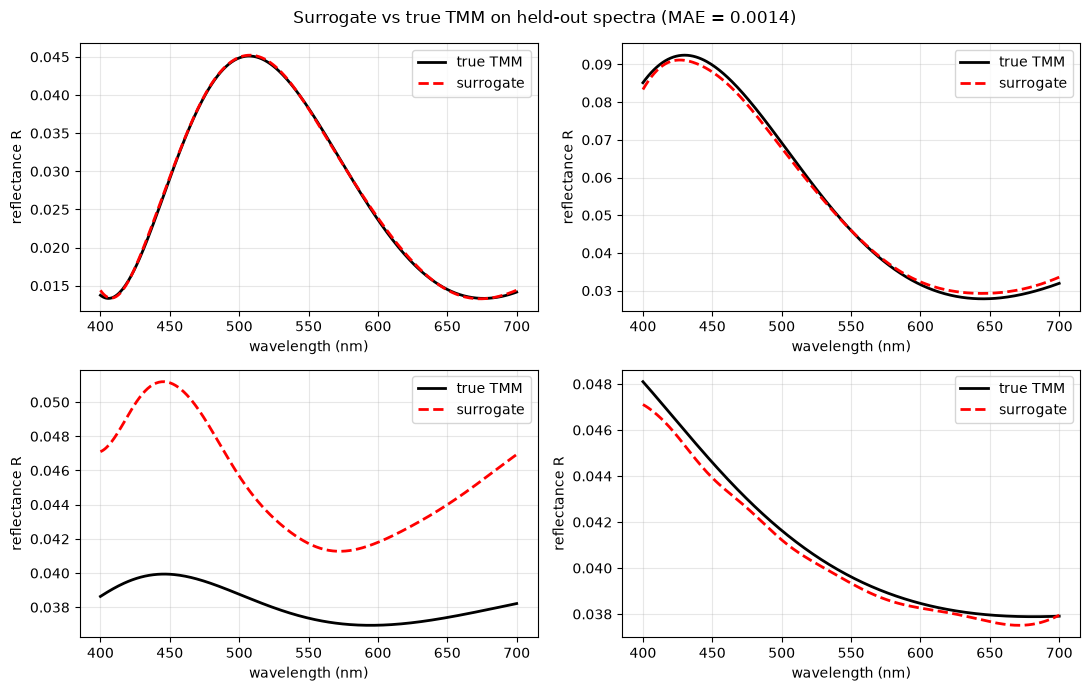

In [12]:
import matplotlib.pyplot as plt

# pick 4 held-out recipes to show
idx_to_show = [0, 1, 2, 3]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, i in zip(axes.flat, idx_to_show):
    ax.plot(wavelengths, Y_test[i], 'k-', lw=2, label='true TMM')
    ax.plot(wavelengths, Y_pred[i], 'r--', lw=2, label='surrogate')
    ax.set_xlabel('wavelength (nm)')
    ax.set_ylabel('reflectance R')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Surrogate vs true TMM on held-out spectra (MAE = {mae:.4f})')
fig.tight_layout()
plt.savefig('surrogate_validation.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
# which held-out recipe was the worst? (bottom-left was idx 2 in the plot)
errors_per_recipe = np.mean(np.abs(Y_pred - Y_test), axis=1)
worst = np.argmax(errors_per_recipe)

print("worst recipe index:", worst, " error:", round(float(errors_per_recipe[worst]), 4))

# un-standardize to see its actual (d, n1, n2) values
worst_params = scaler.inverse_transform(X_test[worst:worst+1])[0]
print("worst recipe params (d, n1, n2):", worst_params.round(2))

# for context: the ranges were d[20,450], n1[1.0,2.5], n2[1.4,1.6]
print("\nranges: d[20,450], n1[1.0,2.5], n2[1.4,1.6]")

worst recipe index: 42  error: 0.0121
worst recipe params (d, n1, n2): [285.15   2.5    1.48]

ranges: d[20,450], n1[1.0,2.5], n2[1.4,1.6]


In [14]:
# TRAIN WIDE: pad the sampling ranges so points-of-interest aren't at the edges
lower_wide = np.array([10.0, 0.9, 1.35])   # slightly below original mins
upper_wide = np.array([460.0, 2.6, 1.65])  # slightly above original maxs

n_samples = 1000
sampler = qmc.LatinHypercube(d=3, seed=2)
samples = qmc.scale(sampler.random(n=n_samples), lower_wide, upper_wide)
Y = np.array([spectrum_for_params(d, n1, n2) for d, n1, n2 in samples])
X = np.array(samples)

# retrain full pipeline
X_scaled = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=200, random_state=0)
pca = PCA(n_components=8)
Y_train_pca = pca.fit_transform(Y_train)
gp = GaussianProcessRegressor(kernel=kernel2, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X_train, Y_train_pca)
Y_pred = pca.inverse_transform(gp.predict(X_test))

mae = np.mean(np.abs(Y_pred - Y_test))
worst_err = np.max(np.mean(np.abs(Y_pred - Y_test), axis=1))
print("overall MAE:", round(float(mae), 5))
print("WORST single-recipe error:", round(float(worst_err), 5))

overall MAE: 0.00278
WORST single-recipe error: 0.03943


In [15]:
# LAST TRY: original tight ranges, but 2000 samples (denser everywhere, incl. edges)
n_samples = 2000
sampler = qmc.LatinHypercube(d=3, seed=3)
samples = qmc.scale(sampler.random(n=n_samples), lower, upper)   # ORIGINAL ranges
Y = np.array([spectrum_for_params(d, n1, n2) for d, n1, n2 in samples])
X = np.array(samples)

X_scaled = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=300, random_state=0)
pca = PCA(n_components=8)
Y_train_pca = pca.fit_transform(Y_train)
gp = GaussianProcessRegressor(kernel=kernel2, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X_train, Y_train_pca)
Y_pred = pca.inverse_transform(gp.predict(X_test))

mae = np.mean(np.abs(Y_pred - Y_test))
worst_err = np.max(np.mean(np.abs(Y_pred - Y_test), axis=1))
print("overall MAE:", round(float(mae), 5))
print("WORST single-recipe error:", round(float(worst_err), 5))

KeyboardInterrupt: 

In [ ]:
# FINAL shippable surrogate: original ranges, 1000 samples (the 0.0014 version)
n_samples = 1000
sampler = qmc.LatinHypercube(d=3, seed=1)
samples = qmc.scale(sampler.random(n=n_samples), lower, upper)
Y = np.array([spectrum_for_params(d, n1, n2) for d, n1, n2 in samples])
X = np.array(samples)

X_scaled = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=200, random_state=0)
pca = PCA(n_components=8)
Y_train_pca = pca.fit_transform(Y_train)
gp = GaussianProcessRegressor(kernel=kernel2, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X_train, Y_train_pca)
Y_pred = pca.inverse_transform(gp.predict(X_test))

mae = np.mean(np.abs(Y_pred - Y_test))
worst_err = np.max(np.mean(np.abs(Y_pred - Y_test), axis=1))
print("FINAL surrogate — overall MAE:", round(float(mae), 5))
print("FINAL surrogate — worst recipe:", round(float(worst_err), 5))

In [ ]:
import matplotlib.pyplot as plt

# pick 4 held-out recipes to show
idx_to_show = [0, 1, 2, 3]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, i in zip(axes.flat, idx_to_show):
    ax.plot(wavelengths, Y_test[i], 'k-', lw=2, label='true TMM')
    ax.plot(wavelengths, Y_pred[i], 'r--', lw=2, label='surrogate')
    ax.set_xlabel('wavelength (nm)')
    ax.set_ylabel('reflectance R')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Surrogate vs true TMM on held-out spectra (MAE = {mae:.4f})')
fig.tight_layout()
plt.savefig('surrogate_validation.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# confirm the trained surrogate is still live
print("gp trained:", hasattr(gp, "X_train_"))
print("pca fitted:", hasattr(pca, "components_"))
print("scaler fitted:", hasattr(scaler, "mean_"))
print("test MAE still:", round(float(np.mean(np.abs(Y_pred - Y_test))), 5))

In [17]:
# Rebuild the GOOD surrogate cleanly (1000 samples, the 0.0014 version)
import jax.numpy as jnp
import numpy as np
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

def tmm_single_layer(n0, n1, n2, d, lam):
    delta = 2 * jnp.pi * n1 * d / lam
    r01 = (n0 - n1) / (n0 + n1)
    r12 = (n1 - n2) / (n1 + n2)
    r = (r01 + r12 * jnp.exp(2j * delta)) / (1 + r01 * r12 * jnp.exp(2j * delta))
    return jnp.abs(r)**2

wavelengths = jnp.linspace(400, 700, 300)
def spectrum_for_params(d, n1, n2):
    R_at = lambda lam: tmm_single_layer(1.0, n1, n2, d, lam)
    return jnp.vectorize(R_at)(wavelengths)

lower = np.array([20.0, 1.0, 1.4])
upper = np.array([450.0, 2.5, 1.6])

# 1000 samples, seed=1 (the good version)
samples = qmc.scale(qmc.LatinHypercube(d=3, seed=1).random(n=1000), lower, upper)
Y = np.array([spectrum_for_params(d, n1, n2) for d, n1, n2 in samples])
X = np.array(samples)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=200, random_state=0)

pca = PCA(n_components=8)
Y_train_pca = pca.fit_transform(Y_train)

kernel2 = (ConstantKernel(1.0,(1e-3,1e3)) * RBF([1.0,1.0,1.0], length_scale_bounds=(1e-2,1e2))
           + WhiteKernel(1e-5, noise_level_bounds=(1e-10,1e-1)))
gp = GaussianProcessRegressor(kernel=kernel2, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X_train, Y_train_pca)

Y_pred = pca.inverse_transform(gp.predict(X_test))
print("surrogate rebuilt, MAE:", round(float(np.mean(np.abs(Y_pred - Y_test))), 5))

surrogate rebuilt, MAE: 0.0014


C:\Users\Buyer\miniconda3\envs\tmmjax\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [18]:
from SALib.sample import sobol as sobol_sample

# Step 2 deliverable: the problem definition (3 params, same ranges as Phase 2)
problem = {
    'num_vars': 3,
    'names': ['d', 'n1', 'n2'],
    'bounds': [[20.0, 450.0], [1.0, 2.5], [1.4, 1.6]]
}

# Step 3 start: Sobol sampling. N*(2D+2) = 1024*(2*3+2) = 8192 samples
param_values = sobol_sample.sample(problem, 1024)
print("Sobol sample shape:", param_values.shape)
print("first 3 rows:\n", param_values[:3])

Sobol sample shape: (8192, 3)
first 3 rows:
 [[353.51639355   1.13952779   1.54152561]
 [440.08312413   1.13952779   1.54152561]
 [353.51639355   1.67533438   1.54152561]]


In [19]:
# evaluate all 8192 Sobol samples through the SURROGATE, then reduce to mean reflectance
X_sobol_scaled = scaler.transform(param_values)      # standardize (same scaler as training)
Y_sobol_pca = gp.predict(X_sobol_scaled)             # GP predicts PCA components
Y_sobol = pca.inverse_transform(Y_sobol_pca)         # rebuild full 300-pt spectra

# our observable: mean reflectance across the band, one number per sample
mean_R = Y_sobol.mean(axis=1)

print("evaluated spectra shape:", Y_sobol.shape)
print("mean_R shape:", mean_R.shape)
print("first 5 mean reflectances:", mean_R[:5].round(4))

evaluated spectra shape: (8192, 300)
mean_R shape: (8192,)
first 5 mean reflectances: [0.0234 0.0231 0.062  0.021  0.0622]


In [20]:
from SALib.analyze import sobol as sobol_analyze

# analyze: how much of the variation in mean_R is due to each parameter?
Si = sobol_analyze.analyze(problem, mean_R, print_to_console=True)


          ST   ST_conf
d   0.113853  0.016489
n1  0.951183  0.072090
n2  0.004912  0.000625
          S1   S1_conf
d   0.033753  0.029468
n1  0.886903  0.074189
n2 -0.000714  0.006227
                S2   S2_conf
(d, n1)   0.076375  0.057046
(d, n2)   0.014973  0.052628
(n1, n2)  0.000734  0.074762


In [21]:
import numpy as np

# run Sobol at EACH wavelength (each column of Y_sobol)
n_wav = Y_sobol.shape[1]   # 300 wavelengths
S1_curves = np.zeros((n_wav, 3))   # first-order index per wavelength, per param
ST_curves = np.zeros((n_wav, 3))   # total-order index per wavelength, per param

for j in range(n_wav):
    Si_j = sobol_analyze.analyze(problem, Y_sobol[:, j], print_to_console=False)
    S1_curves[j] = Si_j['S1']
    ST_curves[j] = Si_j['ST']

print("done. S1_curves shape:", S1_curves.shape)
print("ST_curves shape:", ST_curves.shape)

done. S1_curves shape: (300, 3)
ST_curves shape: (300, 3)


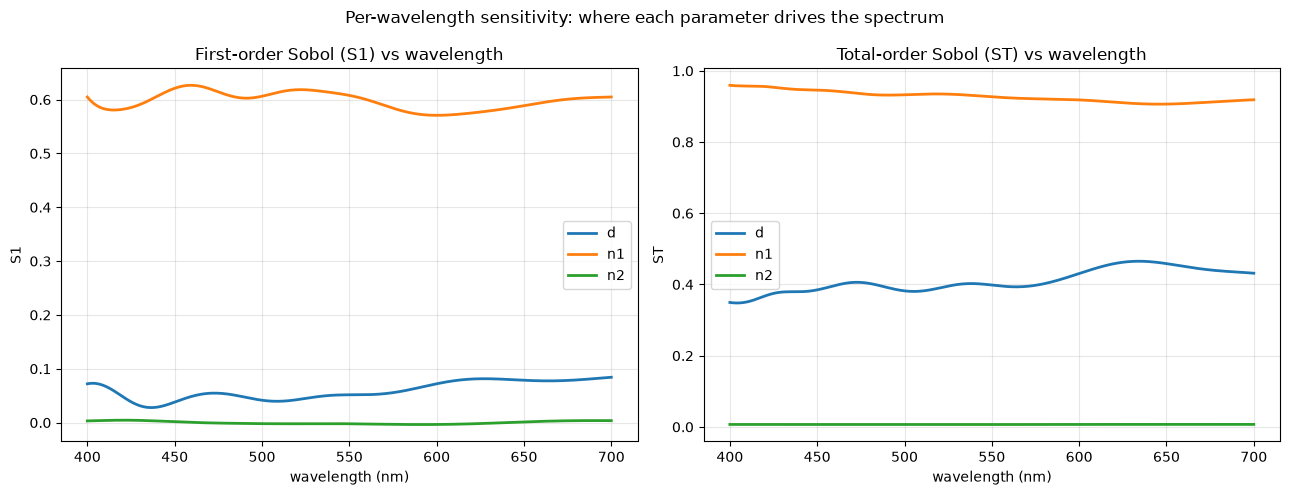

In [22]:
import matplotlib.pyplot as plt

wav = np.array(wavelengths)   # 400-700nm
names = ['d', 'n1', 'n2']
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: first-order (S1) vs wavelength
for k in range(3):
    axes[0].plot(wav, S1_curves[:, k], color=colors[k], lw=2, label=names[k])
axes[0].set_title('First-order Sobol (S1) vs wavelength')
axes[0].set_xlabel('wavelength (nm)'); axes[0].set_ylabel('S1')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# right: total-order (ST) vs wavelength
for k in range(3):
    axes[1].plot(wav, ST_curves[:, k], color=colors[k], lw=2, label=names[k])
axes[1].set_title('Total-order Sobol (ST) vs wavelength')
axes[1].set_xlabel('wavelength (nm)'); axes[1].set_ylabel('ST')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle('Per-wavelength sensitivity: where each parameter drives the spectrum')
fig.tight_layout()
plt.savefig('sensitivity_per_wavelength.png', dpi=120, bbox_inches='tight')
plt.show()

## Phase 3 — Sobol sensitivity findings
- **n1 dominates** reflectance magnitude (S1~0.6, ST~0.9 everywhere) → strongly identifiable.
- **d acts through interaction**, not alone: S1 low (~0.05), ST high (~0.4). The gap is the d×n1 interaction — fringe depth depends on thickness and index together.
- **n2 negligible** everywhere (~0) → unidentifiable from reflectance.
- **Observable matters:** mean reflectance hid d (averaging cancels its oscillation, ST 0.11); per-wavelength revealed it (ST ~0.4).
- **Phase 4 prediction:** n1 recovers cleanly; d correlates with n1 (tangled posterior); n2 stays prior-dominated.